Test Auswertung BA

Absorption 90°C


Einlesen

In [47]:
import pandas as pd

file_path = r"C:\Users\Max\Documents\BA\Daten\PEI25K_5MGML_S1M08.TXT"

columns = [
    "Freq_Hz",
    "Time_s",
    "Eps_real",
    "Eps_imag",
    "Temp_K",
    "MTime_s",
    "Phi_deg",
    "Z_real_Ohm",
    "Z_imag_Ohm",
    "TanPhi"
]

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    skiprows=4,
    names=columns,
    encoding="latin1",
    engine="python"
)

#print(df.to_string())


Unterteilung Spektren

In [49]:
groups = df.groupby(df.index // 24)

#for spec_id, spec in groups:
#    print(spec_id)
#    print(spec.head())

Spektrum $\epsilon'$

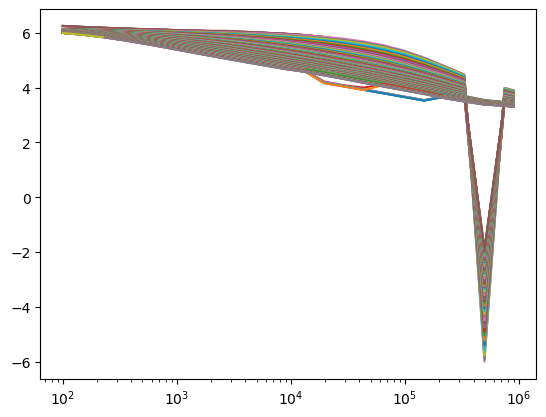

In [46]:
import matplotlib.pyplot as plt

plt.figure()

#groups = df.groupby(df.index // 24)

for spec_id, spec in groups:
    plt.plot(spec["Freq_Hz"], spec["Eps_real"], label=f"Spec {spec_id}")


plt.xscale("log")
#plt.xlim(10**2, 10**5)
#plt.ylim(4, 6.5)
plt.show()

Spektrum $\epsilon''$

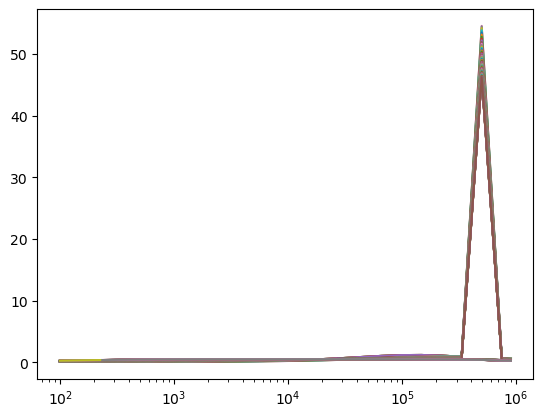

In [28]:
import matplotlib.pyplot as plt

groups = df.groupby(df.index // 24)

for spec_id, spec in groups:
    plt.plot(spec["Freq_Hz"], spec["Eps_imag"], label=f"Spec {spec_id}")

plt.xscale("log")
plt.show()

Zeitverlauf von $\epsilon'$ für eine Frequenz

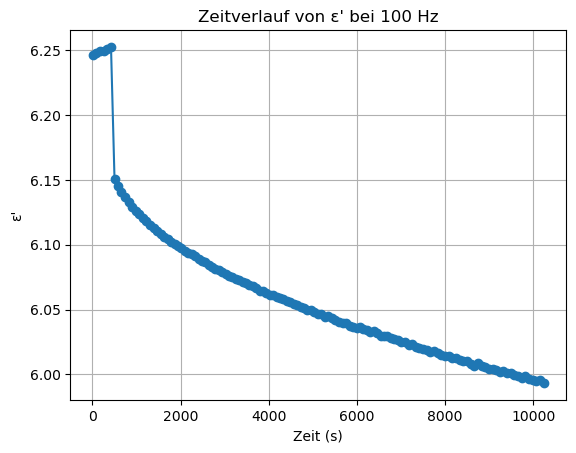

In [39]:
f0 = 100  # <-- HIER gewünschte Frequenz eintragen

# =========================
# 4. Zeitreihe extrahieren
# =========================

time_series = []

for spec_id, spec in groups:
    
    # Zeile mit exakt dieser Frequenz im Spektrum finden
    row = spec[spec["Freq_Hz"] == f0]

    time_series.append([
        spec["MTime_s"].iloc[0],     # Zeit des Spektrums
        row["Eps_real"].values[0]    # ε' bei f0
    ])

# =========================
# 5. In DataFrame umwandeln
# =========================

eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_real"])

# =========================
# 6. Plot
# =========================

plt.figure()
plt.plot(eps_time_df["Time_s"], eps_time_df["Eps_real"], marker="o")

plt.xlabel("Zeit (s)")
plt.ylabel("ε'")
plt.title(f"Zeitverlauf von ε' bei {f0} Hz")
plt.grid(True)

plt.show()

Zeitverlauf von $\epsilon''$ für eine Frequenz

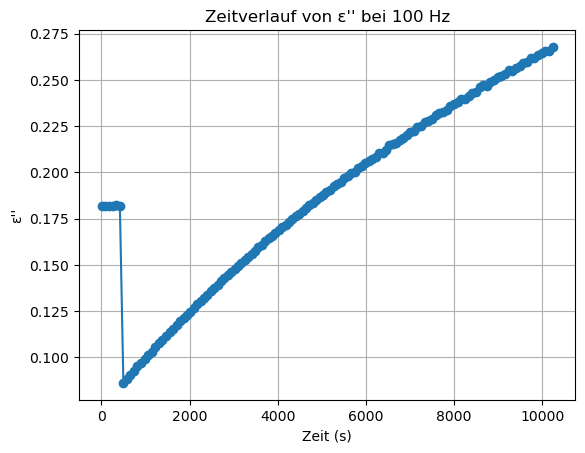

In [34]:
f0 = 100  # <-- HIER gewünschte Frequenz eintragen

# =========================
# 4. Zeitreihe extrahieren
# =========================

time_series = []

for spec_id, spec in groups:
    
    # Zeile mit exakt dieser Frequenz im Spektrum finden
    row = spec[spec["Freq_Hz"] == f0]

    time_series.append([
        spec["MTime_s"].iloc[0],     # Zeit des Spektrums
        row["Eps_imag"].values[0]    # ε'' bei f0
    ])

# =========================
# 5. In DataFrame umwandeln
# =========================

eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_imag"])

# =========================
# 6. Plot
# =========================

plt.figure()
plt.plot(eps_time_df["Time_s"], eps_time_df["Eps_imag"], marker="o")

#plt.yscale("log")
plt.xlabel("Zeit (s)")
plt.ylabel("ε''")
plt.title(f"Zeitverlauf von ε'' bei {f0} Hz")
plt.grid(True)

plt.show()

Zeitverlauf von $\epsilon''$ für mehrere Frequenzen

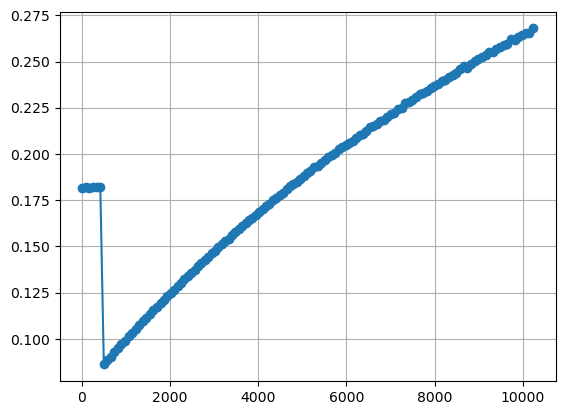

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Frequenzen definieren
# =========================

f_list = [100,
          #12975,
          #9*10**5
         ]  # <-- beliebig erweitern

# =========================
# 2. Gruppieren
# =========================

groups = df.groupby(df.index // 24)

# =========================
# 3. Plot vorbereiten
# =========================

plt.figure()

# =========================
# 4. Schleife über Frequenzen
# =========================

for f0 in f_list:
    
    time_series = []

    for spec_id, spec in groups:

        row = spec[spec["Freq_Hz"] == f0]

        if row.empty:
            continue

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_imag"].iloc[0]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_imag"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_imag"],
        marker="o",
        label=f"{f0} Hz"
    )

# =========================
# 5. Plot Styling
# =========================

#plt.xlabel("Zeit (s)")
#plt.ylabel("ε''")
#plt.title("Zeitverlauf von ε'' für mehrere Frequenzen")
plt.grid(True)
#plt.legend()

plt.show()